## Assignment-6 (100 points)



## Full name: Graysen Gould
## R#: 11944656
## Title of the notebook: Assignment 6
## Date: 11-9-24

In [1]:
# Preamble script block to identify host, user, and kernel
import sys
! hostname
! whoami
print(sys.executable)
print(sys.version)
print(sys.version_info)

GouldPC
gouldpc\gould
C:\Users\gould\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
sys.version_info(major=3, minor=12, micro=4, releaselevel='final', serial=0)


![](https://cdn.dribbble.com/users/1579322/screenshots/6587273/blue_boy_typing_nothought.gif) <br>


## Question0: Video Games (40 pts)<br> 

![](https://media.wired.com/photos/5f7e325a8e38d8a7e74a9f1e/16:9/w_1576,h_886,c_limit/games_gear_libraries_939318912.jpg) <br>

### The "VideoGames.csv" dataset is provided to you:
> This dataset contains a list of video games with sales greater than 100,000 copies. It was generated by a scrape of vgchartz.com.
Fields include:
- Rank - Ranking of overall sales
- Name - The games name
- Platform - Platform of the games release (i.e. PC,PS4, etc.)
- Year - Year of the game's release
- Genre - Genre of the game
- Publisher - Publisher of the game
- Global_Sales - Total worldwide sales (in millions) <br>
<br>
> The script to scrape the data is available at https://github.com/GregorUT/vgchartzScrape.
It is based on BeautifulSoup using Python.
There are 16,598 records. 2 records were dropped due to incomplete information.

### Follow the steps below:
#### A: Import the required library to work with dataframes
#### B: Read the "VideoGames.csv" file
#### C: Check and report if there are any missing values in this dataset. 
#### D: Use the appropriate functions to explain the contents of the dataframe; shape, type, etc.
#### E: Use the appropriate function to get the summary statistics 
#### F: Select a subset of all "Role-Playing" games that were released after 2000
#### G: Based on the global sales, label a game as "high" if sales were above 15 millions, "medium" if sales were between 1 and 15 millions, and "low" if sales were less than 1 million. 


In [2]:
import numpy as np
import pandas as pd

In [28]:
video_games = pd.read_csv("VideoGames.csv")
video_games.head()

,Rank,Name,Platform,Year,Genre,Publisher,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,31.37


In [29]:
print(f"missing values in the dataset: \n")
display(video_games.isnull().sum()) # show columns with missing values

missing values in the dataset: 



Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
Global_Sales      0
dtype: int64

In [33]:
print(f"Shape of Data: {video_games.shape}\n")
display(video_games.info())

Shape of Data: (16598, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   Global_Sales  16598 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 907.8+ KB


None

In [34]:
display(video_games.describe())

,Rank,Year,Global_Sales
count,16598.000000,16327.000000,16598.000000
mean,8300.605254,2006.406443,0.537441
std,4791.853933,5.828981,1.555028
min,1.000000,1980.000000,0.010000
25%,4151.250000,2003.000000,0.060000
50%,8300.500000,2007.000000,0.170000
75%,12449.750000,2010.000000,0.470000
max,16600.000000,2020.000000,82.740000


In [40]:
game_subset = video_games[(video_games["Year"] > 2000) & (video_games["Genre"] == "Role-Playing")]
game_subset.head()

,Rank,Name,Platform,Year,Genre,Publisher,Global_Sales
20,21,Pokemon Diamond/Pokemon Pearl,DS,2006.0,Role-Playing,Nintendo,18.36
25,26,Pokemon Ruby/Pokemon Sapphire,GBA,2002.0,Role-Playing,Nintendo,15.85
26,27,Pokemon Black/Pokemon White,DS,2010.0,Role-Playing,Nintendo,15.32
32,33,Pokemon X/Pokemon Y,3DS,2013.0,Role-Playing,Nintendo,14.35
49,50,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014.0,Role-Playing,Nintendo,11.33


In [162]:
# assining a "High", "Medium", "Low" to the new column "Sales_Rank" based on global_sales
video_games.loc[video_games["Global_Sales"] >= 15, "Sales_Rank"] = "High"
video_games.loc[(video_games["Global_Sales"] < 15) & (video_games["Global_Sales"] >= 1), "Sales_Rank"] = "Medium"
video_games.loc[video_games["Global_Sales"] < 1, "Sales_Rank"] = "Low"

display(video_games.head())
display(video_games[video_games["Sales_Rank"] == "Medium"].head())
display(video_games.tail())

,Rank,Name,Platform,Year,Genre,Publisher,Global_Sales,Sales_Rank
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,82.74,High
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,40.24,High
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,35.82,High
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,33.00,High
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,31.37,High


,Rank,Name,Platform,Year,Genre,Publisher,Global_Sales,Sales_Rank
28,29,Gran Turismo 3: A-Spec,PS2,2001.0,Racing,Sony Computer Entertainment,14.98,Medium
29,30,Call of Duty: Modern Warfare 3,X360,2011.0,Shooter,Activision,14.76,Medium
30,31,Pokémon Yellow: Special Pikachu Edition,GB,1998.0,Role-Playing,Nintendo,14.64,Medium
31,32,Call of Duty: Black Ops,X360,2010.0,Shooter,Activision,14.64,Medium
32,33,Pokemon X/Pokemon Y,3DS,2013.0,Role-Playing,Nintendo,14.35,Medium


,Rank,Name,Platform,Year,Genre,Publisher,Global_Sales,Sales_Rank
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,Low
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,Low
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.01,Low
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.01,Low
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,Low


___
___

### Question 1 - Pandas and Matplotlib libraries (60 pts)

##### **Exercise-1: Import all the libraries - numpy, pandas, and matplotlib so that we do not have to worry about importing the libraries later on in this assignment**


In [59]:
#GIVE YOUR ANSWER FOR EXERCISE-1 IN THIS CELL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Exercise-2: The file named 'Electric_Vehicle_Population_Data.csv' contains the database of electric vehicles registered and operated in different cities and states (primarily Washington State) of the United States. It also contains the vehicle details like make, model, model year, vehicle type, electric range, base retail price and fields that are mostly self explanatory.**

**(POINTS: 60 - each task in this exercise carries 10 points)**

**Task-1:** Read the **Electric_Vehicle_Population_Data.csv** file and store in a variable name **ev_pop**. After reading, display the first 10 rows of the dataframe **ev_pop** as the output.

In [163]:
#GIVE YOUR ANSWER FOR TASK-1 IN THIS CELL
ev_pop = pd.read_csv("Electric_Vehicle_Population_Data.csv")
ev_pop.head(10)

,VIN (1-10),County,City,State,ZIP Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location
0,5YJ3E1EB2K,King,KIRKLAND,WA,98033,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,35000,48.0,478724459,POINT (-122.188994 47.678406)
1,5YJSA1E43L,King,SEATTLE,WA,98102,2020,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,337,0,43.0,112305420,POINT (-122.321673 47.634289)
2,JTDKARFP4J,King,BELLEVUE,WA,98004,2018,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,27300,41.0,209061975,POINT (-122.20316899999999 47.619011)
3,JN1AZ0CP1B,King,SEATTLE,WA,98118,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,32780,37.0,180648065,POINT (-122.275593 47.54055)
4,1N4AZ0CP8F,King,REDMOND,WA,98052,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,29010,45.0,325675787,POINT (-122.122018 47.678465)
5,5YJXCAE2XL,King,SAMMAMISH,WA,98075,2020,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,293,0,41.0,124540307,POINT (-122.028168 47.586173)
6,1G1FX6S04H,King,KENT,WA,98030,2017,CHEVROLET,BOLT,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,37495,47.0,175642190,POINT (-122.19538100000001 47.369696)
7,1N4AZ0CP9D,King,SEATTLE,WA,98103,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75,28800,43.0,226673961,POINT (-122.343577 47.672491)
8,WBY8P6C58K,Snohomish,BOTHELL,WA,98021,2019,BMW,I3S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,153,44450,1.0,332188048,POINT (-122.21210499999998 47.792368)
9,KNDJX3AE8H,King,SEATTLE,WA,98118,2017,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93,32250,37.0,139436888,POINT (-122.275593 47.54055)


**Task-2:** Drop the columns 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location' from the dataframe **ev_pop**. After indexing, display the first 5 rows of the dataframe **ev_pop** as the output. [Hint:The drop() function with 'columns' and 'inplace' argument may be used]

In [164]:
#GIVE YOUR ANSWER FOR TASK-2 IN THIS CELL
ev_pop.drop(columns = ["Clean Alternative Fuel Vehicle (CAFV) Eligibility", "Legislative District", "DOL Vehicle ID", "Vehicle Location"], inplace = True)
ev_pop.head()

,VIN (1-10),County,City,State,ZIP Code,Model Year,Make,Model,Electric Vehicle Type,Electric Range,Base MSRP
0,5YJ3E1EB2K,King,KIRKLAND,WA,98033,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),220,35000
1,5YJSA1E43L,King,SEATTLE,WA,98102,2020,TESLA,MODEL S,Battery Electric Vehicle (BEV),337,0
2,JTDKARFP4J,King,BELLEVUE,WA,98004,2018,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle (PHEV),25,27300
3,JN1AZ0CP1B,King,SEATTLE,WA,98118,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),73,32780
4,1N4AZ0CP8F,King,REDMOND,WA,98052,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),84,29010


Let's say we first want to see whether the EV purchase has generally shown an growth trend over the years. The strategy to visualize it is to have the 'Model Year' (in an ordered manner) in the x-axis and the value counts of that 'Model Year' in the y-axis as a scatter plot.


**Task-3:** Extract the value counts for each 'Model Year' and save the pandas Series in the variable name 'model_year' 

In [165]:
#GIVE YOUR ANSWER FOR TASK-3 IN THIS CELL
model_year = ev_pop["Model Year"].value_counts().sort_index(ascending = False)
model_year

Model Year
2021      946
2020     9154
2019    10345
2018    13256
2017     8106
2016     6274
2015     5030
2014     3772
2013     4891
2012     1737
2011      880
2010       31
2008       23
2002        2
2000        6
1999        3
1998        1
1997        1
1993        1
Name: count, dtype: int64

At this point model_year is a pandas Series having the 'Model Year' values as its index and count of values as the Series. 

If we explore the dataset we shall see the 'Base MSRP' column inexplacably contain a good number of values equal to 'zero' and in some case unusually high values (can be disregarded as outlier) which are greater than 100,000.

**Task-4:** Plot a scatter plot with the Model Year values in the x-axis and their value counts in the y-axis. Make sure the plot has proper labels and title. [Hint: You can use Series.index attribute to have model year as a data sequence]. Comment on your observations in a following markdown cell.


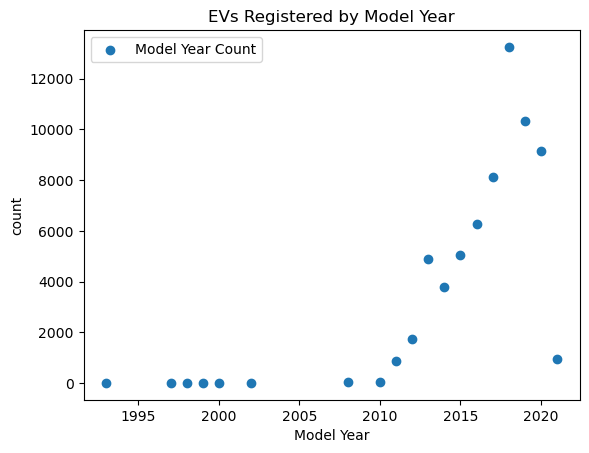

In [171]:
#GIVE YOUR ANSWER FOR TASK-4 IN THIS CELL
plt.scatter(model_year.index, model_year, label = "Model Year Count")
plt.title("EVs Registered by Model Year")
plt.legend()
plt.xlabel("Model Year")
plt.ylabel("count")
plt.show()

It appears that usage per model year increased up to about 2018. After the number of cars registerd per model year begins to decrease.

Student Answer (Expected): The observation is the EV usage or purchase shown a general trend of exponential growth which might be slowed down in last couple of years due to COVID and other challenging situations.

Let's work towards plotting a histogram for 'MRSP Base Price' value of the entire EV Population database with the following two tasks.

**Task-5:** Clean up the ev_pop dataframe by selecting only the rows of the dataframe where the two conditions: 
    a) the Base MSRP is greater than 0
    b) the base MSRP is less than or equal to 100000
are simultaneously met (**and** operation).Save the modified dataframe as **ev_pop_cleaned**

In [172]:
#GIVE YOUR ANSWER FOR TASK-5 IN THIS CELL
ev_pop_cleaned = ev_pop[(ev_pop["Base MSRP"] > 0) & (ev_pop["Base MSRP"] <= 100000)]
ev_pop_cleaned.describe()

,ZIP Code,Model Year,Electric Range,Base MSRP
count,53827.000000,53827.000000,53827.000000,53827.000000
mean,98217.398034,2016.485165,126.420941,40889.499043
std,1650.833566,2.173967,85.270723,15711.328121
min,320.000000,2008.000000,6.000000,22995.000000
25%,98052.000000,2015.000000,47.000000,31635.000000
50%,98119.000000,2017.000000,93.000000,35000.000000
75%,98368.000000,2018.000000,215.000000,39145.000000
max,99801.000000,2020.000000,289.000000,99600.000000


**Task-6:** Plot the Histogram of the 'Base MSRP' series of the **ev_pop_cleaned** dataframe 



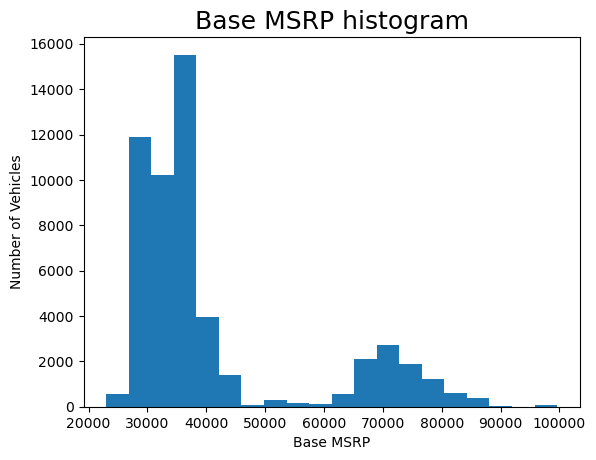

In [173]:
#GIVE YOUR ANSWER FOR TASK-6 IN THIS CELL
plt.hist(ev_pop_cleaned["Base MSRP"], bins = 20)
plt.title("Base MSRP histogram", fontsize = 18)
plt.xlabel("Base MSRP")
plt.ylabel("Number of Vehicles")

plt.show()

**EXTRA Exercise (Optional): In this exercise, we shall visualize the data from the manufacturer's perspective through following four tasks"**
(BONUS 20 PTS)

**Task-1:** Using the **ev_pop** dataframe, extract the top ten makers of electric vehicles by the dataset. Print the names of the makers and their corresponding value counts (no. of vehicles by the maker). [Hint: Use the **value_counts()** and **nlargest()** functions in tendem to extract the series of top ten makers]

In [174]:
#GIVE YOUR ANSWER FOR TASK-1 IN THIS CELL
top_makes = ev_pop["Make"].value_counts().nlargest(10)
top_makes

Make
TESLA         25880
NISSAN        11220
CHEVROLET      8382
FORD           3671
TOYOTA         2832
BMW            2626
KIA            2262
AUDI           1113
VOLKSWAGEN      971
HYUNDAI         880
Name: count, dtype: int64

**Task-2:** Make a bar plot for the top ten makers and their vehicle counts in the **ev_pop** database. Use all the proper plotting practices for labels and title. For better readability make sure the x labels are rotated 90 degrees.

**Hint**: Use the xticks.rotation() function for the label rotation. Use pyplot.show() to avoid unwanted texts above the bar graph.

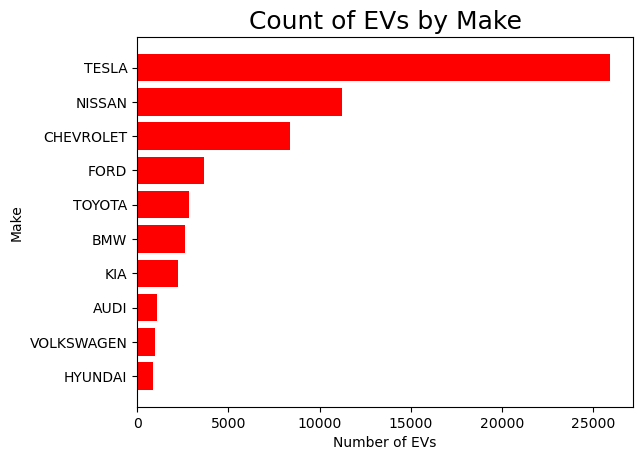

In [125]:
#GIVE YOUR ANSWER FOR TASK-2 IN THIS CELL
plt.barh(top_makes.sort_values(ascending = True).index, top_makes.sort_values(ascending = True), color = "red")

plt.title("Count of EVs by Make", fontsize = 18)
plt.ylabel("Make")
plt.xlabel("Number of EVs")
# did not need xticks.rotation()

plt.show()

Now we want to observe the sales (revenue) trend of the top two manufacturers through the following tasks.

**Task-3:** Extract two separate dataframes for the top two manufacturers where the 'Make' column value of **ev_pop** matches with the manufacturer. Sort the two dataframes by the ascending values for 'Model Year' and save the two sorted dataframes as **sorted_Tesla** and **sorted_Nissan**. Apply the **groupby()** and **sum()** function together for grouping the sorted dataframes by 'Model Year' and get the summation for numerical fields. It will extract two dataframes (name them **tesla** and **nissan** respectively) which will provide the yearly sum of numerical columns like 'Electric Range' and 'Base MSRP'.


In [140]:
#GIVE YOUR ANSWER FOR TASK-3 IN THIS CELL
sorted_Tesla = ev_pop[ev_pop["Make"] == "TESLA"].sort_values(by = "Model Year", ascending = False)
sorted_Nissan = ev_pop[ev_pop["Make"] == "NISSAN"].sort_values(by = "Model Year", ascending = False)
tesla = sorted_Tesla.groupby("Model Year")[["Electric Range", "Base MSRP"]].sum()
nissan = sorted_Nissan.groupby("Model Year")[["Electric Range", "Base MSRP"]].sum()
display(tesla.head())
display(nissan.head())

,Electric Range,Base MSRP
Model Year,,
2008,5060,2275850
2010,7595,3439450
2011,1715,763000
2012,36835,8326100
2013,173264,58226700


,Electric Range,Base MSRP
Model Year,,
2011,58108,26092880
2012,45917,22140800
2013,153825,59068800
2014,60312,20807640
2015,159936,55235040


**Task-4:** Plot an overlaid line plot for 'Model Year' (vs.) 'Revenue (=summed up Base MSRP)' for each of the top two manufacturers. The plot must display an x-label, a y-label, a title, and a legend.

**Note-1:** To increase the line width of the line plot, use the argument **`lw`**. For example: lw = 3.

**Note-2:** To give your own labels for each color that corresponds to one of the 4 countries, use the argument **`label`**. For example: label = 'Tesla'.

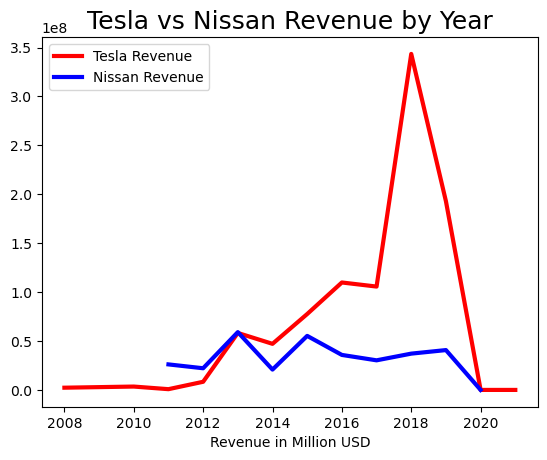

In [160]:
#GIVE YOUR ANSWER FOR TASK-4 IN THIS CELL
plt.plot(tesla.index, tesla["Base MSRP"], color = "red", label = "Tesla Revenue", lw = 3)
plt.plot(nissan.index, nissan["Base MSRP"], color = "blue", label = "Nissan Revenue", lw = 3)

plt.title("Tesla vs Nissan Revenue by Year", fontsize = 18)
plt.xlabel("Model Year")
plt.xlabel("Revenue in Million USD")

plt.legend()
plt.show()

![](https://freight.cargo.site/w/1200/i/c96b2ce17b2aee95c6e837552e3e38d058ac4ad2a6759448ed78128963790744/Happy_Coding_BC_6-03-05.png)